In [1]:
# 1. Velocidad de convergencia: grafica del error vs n en escala log-log

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

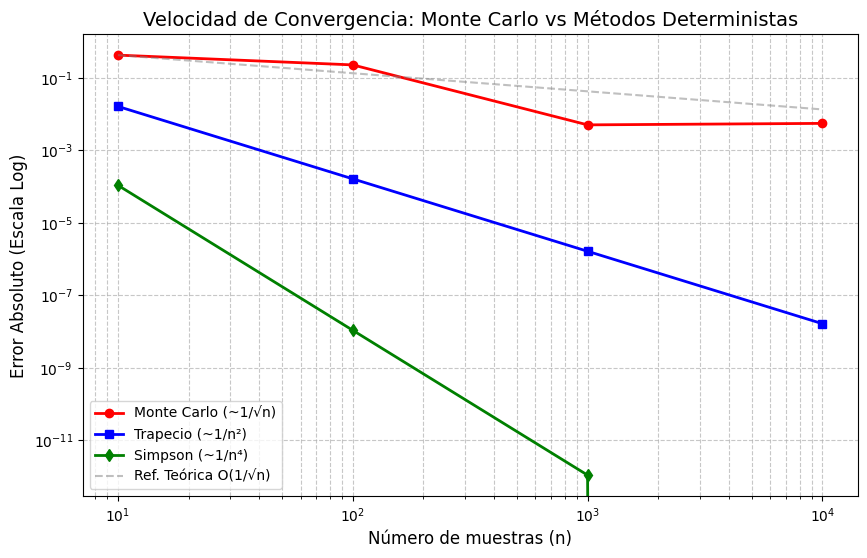

In [3]:
# --- FUNCIONES DE INTEGRACIÓN 

def simular_montecarlo_sin(n, semilla=42):
    rng = np.random.default_rng(semilla)
    x = rng.uniform(0, np.pi, n)
    y = rng.uniform(0, 1, n)
    dentro = y <= np.sin(x)
    sin_aprox = dentro.mean() * np.pi
    valor_real = 2.0  # Integral de sin(x) de 0 a pi
    return {"n": n, "sin_aprox": sin_aprox, "error_abs": abs(sin_aprox - valor_real)}

def simular_trapecio_sin(n):
    x = np.linspace(0, np.pi, n + 1)
    y = np.sin(x)
    # Regla del trapecio: (h/2) * (f(a) + 2*sum(f(xi)) + f(b))
    h = np.pi / n
    sin_aprox = (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])
    return {"n": n, "sin_aprox": sin_aprox, "error_abs": abs(sin_aprox - 2.0)}

def simular_simpson_sin(n):
    # n debe ser par para Simpson 1/3
    if n % 2 != 0: n += 1
    x = np.linspace(0, np.pi, n + 1)
    y = np.sin(x)
    h = np.pi / n
    # f(x0) + 4*sum(impares) + 2*sum(pares) + f(xn)
    sin_aprox = (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1])
    return {"n": n, "sin_aprox": sin_aprox, "error_abs": abs(sin_aprox - 2.0)}

# --- CÁLCULOS

muestras = [10, 100, 1000, 10000]

# Ejecutamos las simulaciones de forma independiente
resultados_mc = [simular_montecarlo_sin(n) for n in muestras]
resultados_tr = [simular_trapecio_sin(n) for n in muestras]
resultados_sm = [simular_simpson_sin(n) for n in muestras]

# Extraemos solo los errores para graficar
error_mc = [r["error_abs"] for r in resultados_mc]
error_tr = [r["error_abs"] for r in resultados_tr]
error_sm = [r["error_abs"] for r in resultados_sm]

# --- 2. GRÁFICO LOG-LOG ---
plt.figure(figsize=(10, 6))

plt.loglog(muestras, error_mc, 'o-', label='Monte Carlo (~1/√n)', color='red', linewidth=2)
plt.loglog(muestras, error_tr, 's-', label='Trapecio (~1/n²)', color='blue', linewidth=2)
plt.loglog(muestras, error_sm, 'd-', label='Simpson (~1/n⁴)', color='green', linewidth=2)

# Línea de referencia teórica para Monte Carlo
referencia = [error_mc[0] * (muestras[0]/n)**0.5 for n in muestras]
plt.loglog(muestras, referencia, '--', color='gray', alpha=0.5, label='Ref. Teórica O(1/√n)')

plt.title('Velocidad de Convergencia: Monte Carlo vs Métodos Deterministas', fontsize=14)
plt.xlabel('Número de muestras (n)', fontsize=12)
plt.ylabel('Error Absoluto (Escala Log)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend()
plt.show()



In [4]:
# 2. Efecto de la semilla: repetir la estimación de π con 20 semillas distintas para cada n. Graficar la media ± desviación estándar. ¿Cuántos puntos se necesitan para tener un error < 0,01 con 95 % de confianza?


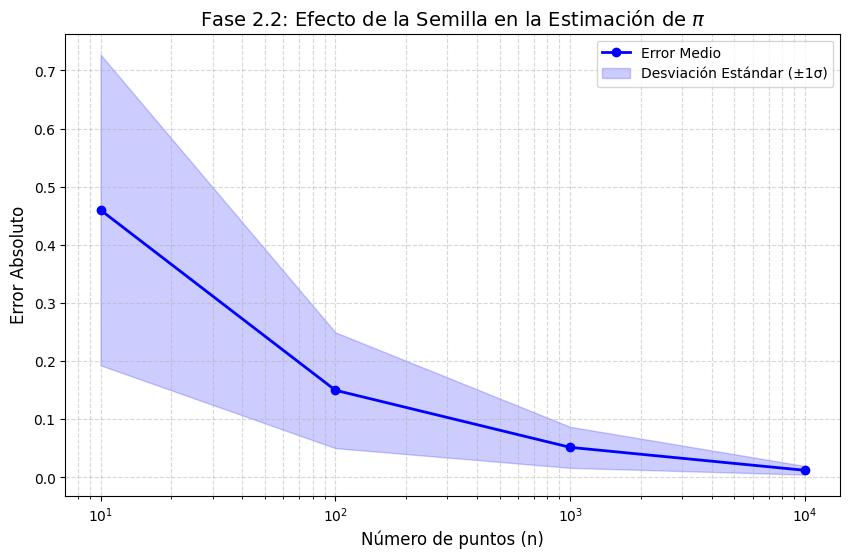

ANÁLISIS ESTADÍSTICO (Fase 2.2):
----------------------------------------
Objetivo: Error < 0.01 con 95% de confianza.
Valor de Z utilizado: 1.96
n teórico necesario: 103599 puntos.


In [5]:
# --- FUNCIÓN INDEPENDIENTE
def simular_pi(n, semilla=42):
    """Estima pi usando el método del disco (Monte Carlo)."""
    rng = np.random.default_rng(semilla)
    # Generar puntos en el cuadrado [-1, 1] x [-1, 1]
    x = rng.uniform(-1, 1, n)
    y = rng.uniform(-1, 1, n)
    
    # Condición: punto dentro del círculo unitario (x^2 + y^2 <= 1)
    distancia_al_centro = x**2 + y**2
    dentro = distancia_al_centro <= 1
    
    # pi_aprox = 4 * (puntos_dentro / n_total)
    pi_aprox = 4 * dentro.mean()
    error_abs = abs(pi_aprox - np.pi)
    
    return {"pi_aprox": pi_aprox, "error_abs": error_abs}

# --- 1. REPETIR ESTIMACIÓN CON 20 SEMILLAS 
muestras = [10, 100, 1000, 10000]
n_semillas = 20
resultados_semillas = []

for n in muestras:
    errores_n = []
    for i in range(n_semillas):
        # Ahora simular_pi ya está definida arriba
        r = simular_pi(n, semilla=i)
        errores_n.append(r["error_abs"])
    resultados_semillas.append(errores_n)

# Convertimos a matriz de numpy: filas (n), columnas (semillas)
errores_matrix = np.array(resultados_semillas)

medias = errores_matrix.mean(axis=1)
desviaciones = errores_matrix.std(axis=1)

# --- 2. GRAFICAR MEDIA ± DESVIACIÓN ESTÁNDAR 
plt.figure(figsize=(10, 6))

plt.plot(muestras, medias, 'o-', label='Error Medio', color='blue', linewidth=2)
plt.fill_between(muestras, medias - desviaciones, medias + desviaciones, 
                 color='blue', alpha=0.2, label='Desviación Estándar (±1σ)')

plt.xscale('log')
# CORRECCIÓN AQUÍ: Agregada la 'r' inicial para evitar el SyntaxWarning de \pi
plt.title(r'Fase 2.2: Efecto de la Semilla en la Estimación de $\pi$', fontsize=14);
plt.xlabel('Número de puntos (n)', fontsize=12);
plt.ylabel('Error Absoluto', fontsize=12);
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# --- 3. CÁLCULO DE N PARA CONFIANZA DEL 95% 
"""
Para un intervalo de confianza del 95%, usamos Z ≈ 1.96.
La fórmula del error en Montecarlo para proporciones es:
Error = Z * sqrt( (p * (1-p)) / n ) * 4
Donde p es pi/4. Despejando n:
n = (Z^2 * p * (1-p) * 16) / (Error_objetivo^2)
"""
p_teorico = np.pi / 4
Z = 1.96
error_obj = 0.01

n_necesario = ( (Z**2) * p_teorico * (1 - p_teorico) * 16 ) / (error_obj**2)

print(f"ANÁLISIS ESTADÍSTICO (Fase 2.2):")
print("-" * 40)
print(f"Objetivo: Error < {error_obj} con 95% de confianza.")
print(f"Valor de Z utilizado: {Z}")
print(f"n teórico necesario: {math.ceil(n_necesario)} puntos.")

In [6]:
# 3. Integrales en 2D: generalizar Monte Carlo para calcular el área de una región irregular {(x, y) : x**2 + y**4 ≤ 1}). Comparación con una estimación por cuadrícula fina

FileNotFoundError: [Errno 2] No such file or directory: '../figs/tabla_resultados_area_2d.png'

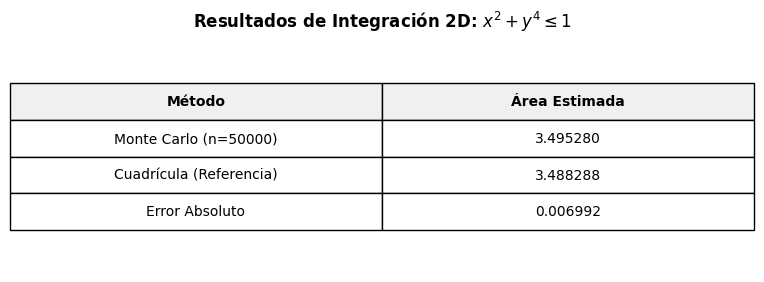

In [7]:
# --- 1. FUNCIÓN DE MONTE CARLO 2D 
def simular_area_irregular(n, semilla=42):
    rng = np.random.default_rng(semilla)
    x = rng.uniform(-1, 1, n)
    y = rng.uniform(-1, 1, n)
    
    dentro = (x**2 + y**4) <= 1
    area_aprox = dentro.mean() * 4
    return x, y, dentro, area_aprox

# --- 2. ESTIMACIÓN POR CUADRÍCULA (GRID) 
def estimar_por_cuadricula(resolucion=1000):
    x_range = np.linspace(-1, 1, resolucion)
    y_range = np.linspace(-1, 1, resolucion)
    X, Y = np.meshgrid(x_range, y_range)
    
    dentro_grid = (X**2 + Y**4) <= 1
    area_grid = dentro_grid.mean() * 4
    return area_grid

# --- 3. EJECUCIÓN 
n_muestras = 50000  # <--- Definimos n_muestras
x, y, dentro, area_mc = simular_area_irregular(n_muestras) # <--- Obtenemos area_mc
area_ref = estimar_por_cuadricula() # <--- Obtenemos area_ref

# --- 4. VISUALIZACIÓN DE RESULTADOS 
# 1. Preparar los datos desde los resultados
error_abs_2d = abs(area_mc - area_ref)
col_labels = ["Método", "Área Estimada"]
data_tabla = [
    [f"Monte Carlo (n={n_muestras})", f"{area_mc:.6f}"],
    ["Cuadrícula (Referencia)", f"{area_ref:.6f}"],
    ["Error Absoluto", f"{error_abs_2d:.6f}"]
]

# 2. Configurar la visualización
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
ax.axis('tight')

# 3. Crear la tabla 
tabla = ax.table(cellText=data_tabla, colLabels=col_labels, loc='center', cellLoc='center')

# 4. Estilo de la tabla 
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 2.2)

# Estética del encabezado (Negrita y fondo gris)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f0f0f0')

# 5. Título y Guardado
plt.title(r"Resultados de Integración 2D: $x^2 + y^4 \leq 1$", fontsize=12, pad=10, fontweight='bold')
plt.savefig("../figs/tabla_resultados_area_2d.png", bbox_inches='tight', dpi=300)
plt.show()

# --- 5. GRÁFICO DE LA REGIÓN
plt.figure(figsize=(8, 8))
n_plot = 5000
plt.scatter(x[:n_plot][dentro[:n_plot]], y[:n_plot][dentro[:n_plot]], 
            color='blue', s=1, alpha=0.5, label='Dentro de la región')
plt.scatter(x[:n_plot][~dentro[:n_plot]], y[:n_plot][~dentro[:n_plot]], 
            color='red', s=1, alpha=0.3, label='Fuera de la región')

plt.title(r'Integración 2D sobre Región Irregular: $x^2 + y^4 \leq 1$', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.legend(loc='upper right')
plt.gca().set_aspect('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show();

In [ ]:
# 4 Buffon: implementar la aguja de Buffon para estimar π. Comparar la convergencia con el método del disco

In [ ]:
def simular_buffon(n, semilla=42):
    """Estima pi usando el experimento de la aguja de Buffon."""
    rng = np.random.default_rng(semilla)
    
    # 1. Distancia del centro a la línea más cercana
    # d=1, por lo que el centro está a máximo 0.5 de una línea
    x_centro = rng.uniform(0, 0.5, n)
    
    # 2. Ángulo aleatorio
    theta = rng.uniform(0, np.pi/2, n)
    
    # 3. Condición de cruce (L=1)
    cruza = x_centro <= 0.5 * np.sin(theta)
    n_cruces = np.sum(cruza)
    
    # Cálculo de pi: P = 2L / (d * pi) -> pi = 2 / P (si L=d=1)
    if n_cruces > 0:
        proporcion = n_cruces / n
        pi_aprox = 2 / proporcion
    else:
        pi_aprox = 0 #No hubo cruces
        
    error_abs = abs(pi_aprox - np.pi)
    
    return {
        "n": n,
        "pi_aprox": pi_aprox,
        "error_abs": error_abs
    }


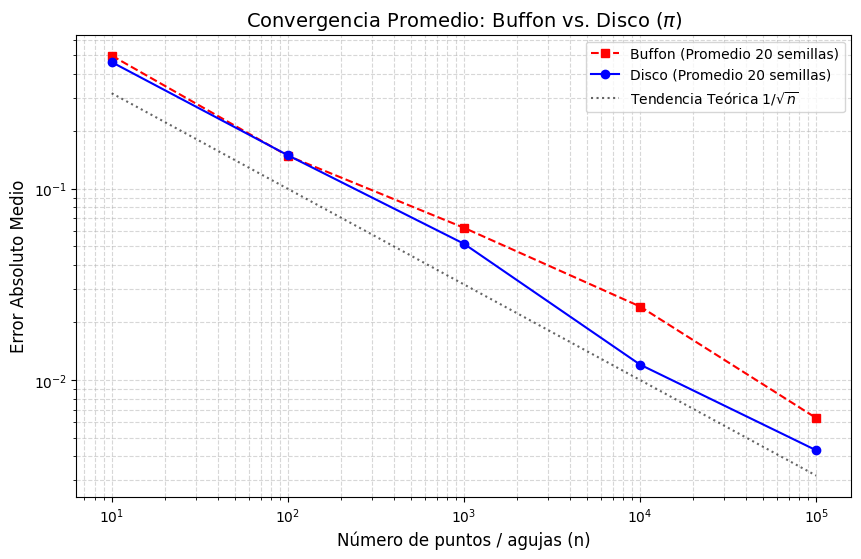

In [ ]:
# --- 1. SIMULACIÓN CON MÚLTIPLES SEMILLAS
muestras = [10, 100, 1000, 10000, 100000]
n_semillas = 20

errores_disco_avg = []
errores_buffon_avg = []

for n in muestras:
    # Ejecutar 20 veces con semillas distintas para el Disco
    err_d_temp = [simular_pi(n, semilla=s)["error_abs"] for s in range(n_semillas)]
    # Ejecutar 20 veces con semillas distintas para Buffon
    err_b_temp = [simular_buffon(n, semilla=s)["error_abs"] for s in range(n_semillas)]
    
    # Guardamos el promedio de los errores para este 'n'
    errores_disco_avg.append(np.mean(err_d_temp))
    errores_buffon_avg.append(np.mean(err_b_temp))

# --- 2. GRÁFICO DE CONVERGENCIA PROMEDIO
plt.figure(figsize=(10, 6))

# Graficar promedios
plt.plot(muestras, errores_buffon_avg, 's--', label='Buffon (Promedio 20 semillas)', color='red')
plt.plot(muestras, errores_disco_avg, 'o-', label='Disco (Promedio 20 semillas)', color='blue')

# Tendencia teórica 1/sqrt(n)
n_ref = np.array(muestras)
plt.plot(n_ref, 1/np.sqrt(n_ref), 'k:', alpha=0.6, label=r'Tendencia Teórica $1/\sqrt{n}$')

plt.xscale('log')
plt.yscale('log')

plt.title(r'Convergencia Promedio: Buffon vs. Disco ($\pi$)', fontsize=14)
plt.xlabel('Número de puntos / agujas (n)', fontsize=12)
plt.ylabel('Error Absoluto Medio', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.savefig("../figs/convergencia_promedio_pi.png", bbox_inches='tight', dpi=300)
plt.show()